In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Preparação dos dados

In [2]:
# Carregar dados
df = pd.read_csv(r'C:\FACULDADE\github\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv', sep=',')

# Prepara a coluna de datas para o split temporal ANTES de apagá-la do dataset principal
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime('2018-07-01', utc=True)
date_col = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Remover colunas conforme solicitado (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / Pós-compra (ocorrem após aprovação ou derivam do tempo de entrega)
    'order_delivered_customer_date', 
    'order_delivered_carrier_date',
    'review_score', 
    # 'delivered_on_time', # Vamos manter esta no df principal apenas para análises descritivas, não passaremos ela para 'X'.
    'approval_time_hours', 
    'handling_time_hours', 
    'shipping_delay_hours',
    
    # Variáveis climáticas (Vendedor)
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    
    # Variáveis climáticas (Cliente)
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',

    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru','customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]

df = df.drop(columns=colunas_remover) 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33820 entries, 0 to 33819
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   holiday_at_shipping       33820 non-null  int64  
 1   delivery_time_days        33820 non-null  float64
 2   purchase_hour             33820 non-null  int64  
 3   purchase_day_of_week      33820 non-null  int64  
 4   is_weekend                33820 non-null  int64  
 5   price                     33820 non-null  float64
 6   freight_value             33820 non-null  float64
 7   product_weight_g          33820 non-null  int64  
 8   volume_cm3                33820 non-null  float64
 9   distance_km               33820 non-null  float64
 10  same_city                 33820 non-null  int64  
 11  delivered_on_time         33820 non-null  int64  
 12  seller_geolocation_lat    33820 non-null  float64
 13  seller_geolocation_lng    33820 non-null  float64
 14  customer_geolocat

## Verificando nulos

In [4]:
# Mostra a quantidade de nulos em cada coluna
print(df.isnull().sum().sort_values(ascending=False))

holiday_at_shipping         0
delivery_time_days          0
purchase_hour               0
purchase_day_of_week        0
is_weekend                  0
price                       0
freight_value               0
product_weight_g            0
volume_cm3                  0
distance_km                 0
same_city                   0
delivered_on_time           0
seller_geolocation_lat      0
seller_geolocation_lng      0
customer_geolocation_lat    0
customer_geolocation_lng    0
month                       0
dtype: int64


## Heatmap para ver a maior correlação

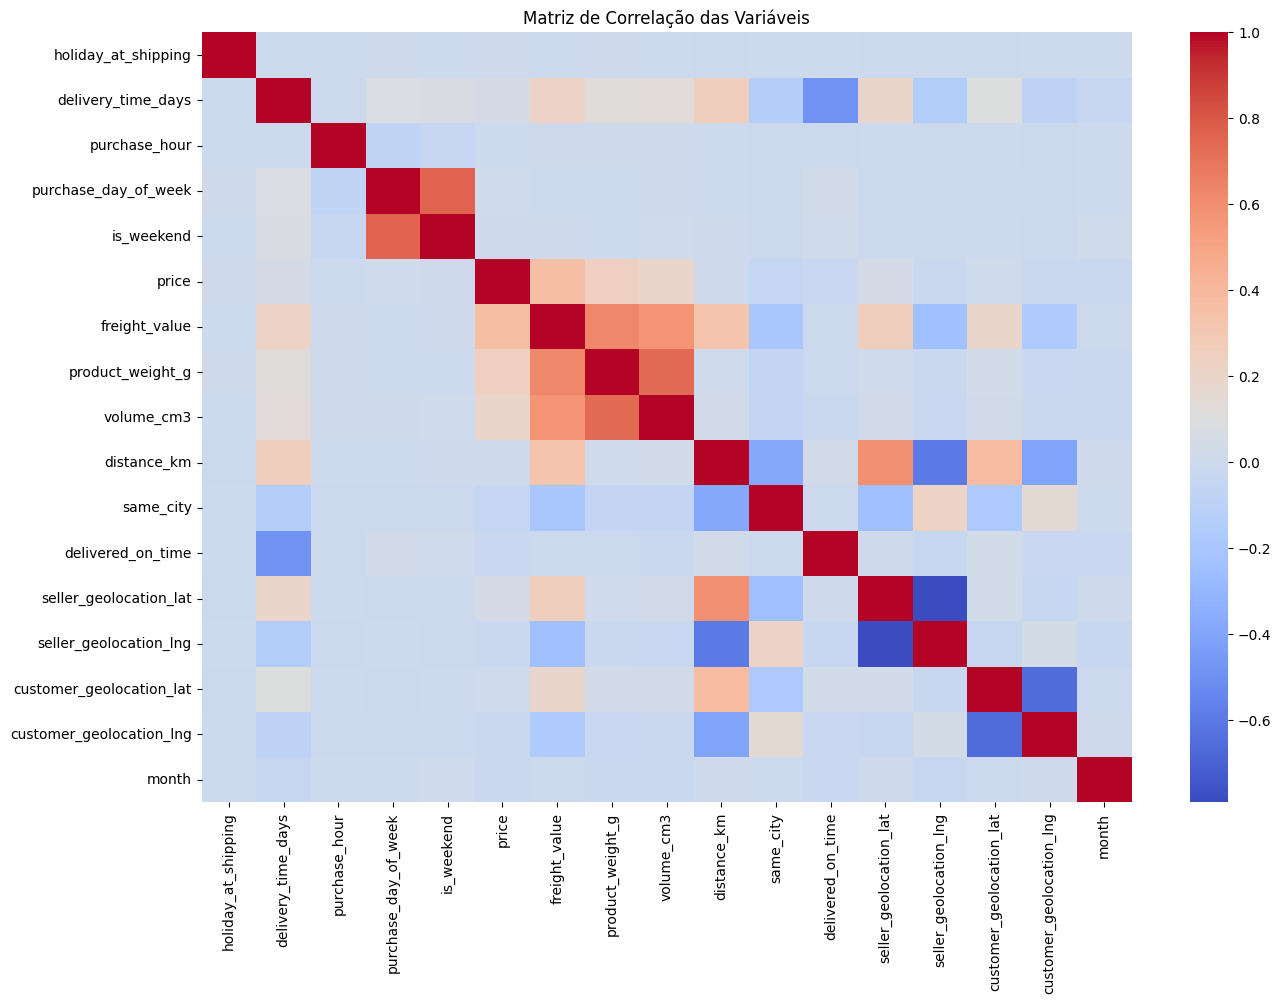

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [6]:
# Verificando a correlação (agora ignorando colunas de texto/data)
correlacao = df.corr(numeric_only=True)
print(correlacao['delivery_time_days'].sort_values(ascending=False).head(20))

delivery_time_days          1.000000
distance_km                 0.252284
freight_value               0.218740
seller_geolocation_lat      0.193206
volume_cm3                  0.130162
product_weight_g            0.123101
customer_geolocation_lat    0.100463
purchase_day_of_week        0.082317
is_weekend                  0.072852
price                       0.046499
holiday_at_shipping         0.005365
purchase_hour              -0.001271
month                      -0.039021
customer_geolocation_lng   -0.090585
same_city                  -0.135635
seller_geolocation_lng     -0.145391
delivered_on_time          -0.496131
Name: delivery_time_days, dtype: float64


## Relacionando Variáveis
### 3 Variáveis com a maior correlação:
* `distance_km` ->                       0.252284
* `freight_value`  ->                     0.218740
* `seller_geolocation_lat`             ->                   0.193206

In [7]:
%pip install plotly
# importando as visualizações
import seaborn as sns
import plotly.express as px

Note: you may need to restart the kernel to use updated packages.


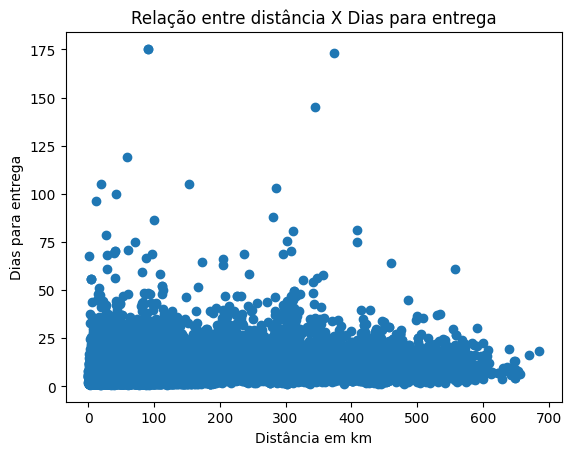

In [8]:
plt.scatter(df['distance_km'], df['delivery_time_days'])
plt.title('Relação entre distância X Dias para entrega')
plt.xlabel('Distância em km')
plt.ylabel('Dias para entrega')
plt.show()

In [9]:
px.scatter(df, x = 'distance_km', y = 'delivery_time_days', 
           trendline_color_override="red", trendline='ols')

## Distribuição do delivery_time_days 
### Utilizando histograma e boxplot

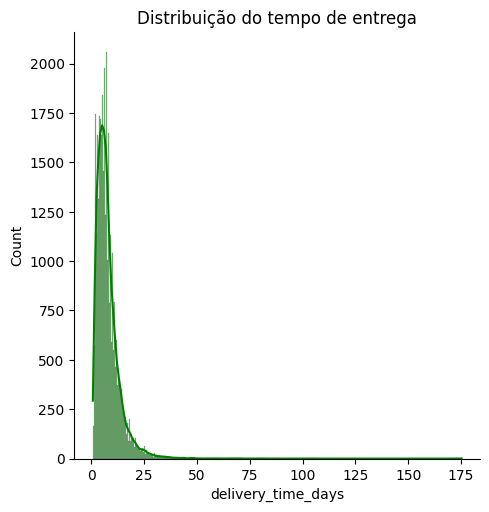

In [10]:
sns.displot(df['delivery_time_days'], kde=True, color='green')
plt.title('Distribuição do tempo de entrega')
plt.show()

Pode-se observar que o gráfico está assimétrico -> Influência desproporcional de valores altos: Valores muito grandes "puxam" a reta da regressão, prejudicando a precisão para a maioria dos dados.

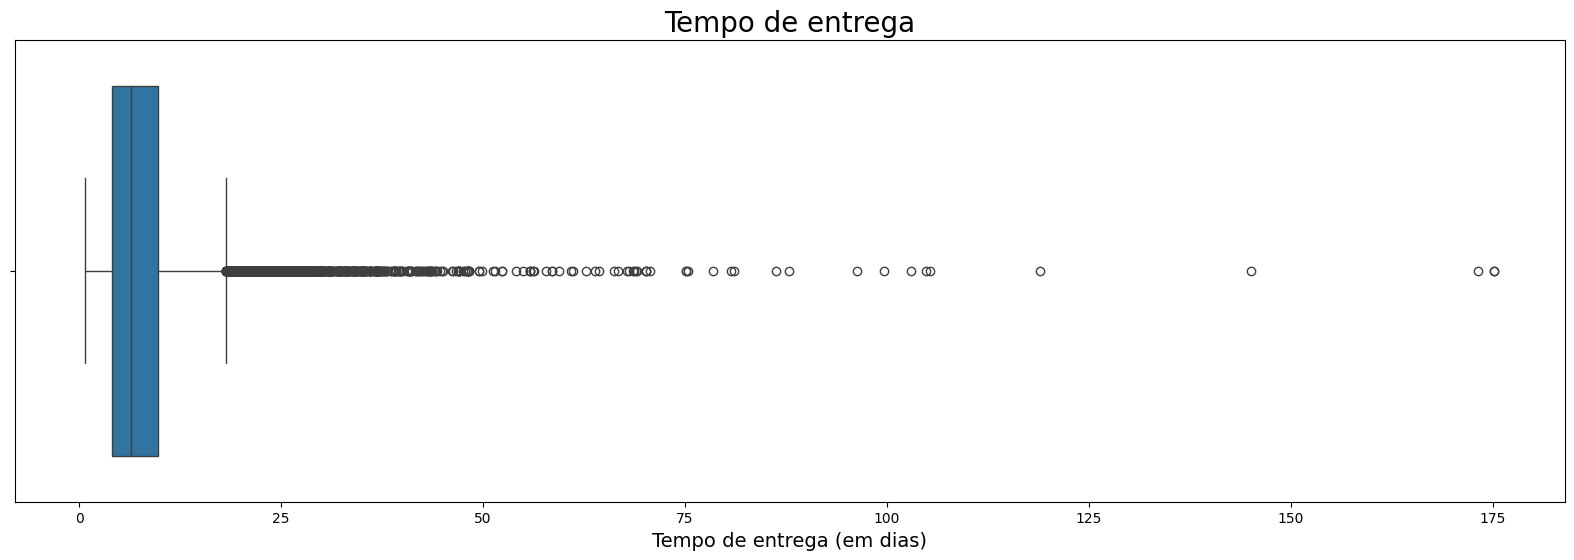

In [11]:
ax = sns.boxplot(x='delivery_time_days', data=df)

ax.figure.set_size_inches(20, 6)
ax.set_title('Tempo de entrega', fontsize=20)
ax.set_xlabel('Tempo de entrega (em dias)', fontsize=14)
plt.show()

## Analisando as variáveis independentes

In [12]:
df.columns

Index(['holiday_at_shipping', 'delivery_time_days', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'delivered_on_time', 'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng', 'month'],
      dtype='str')

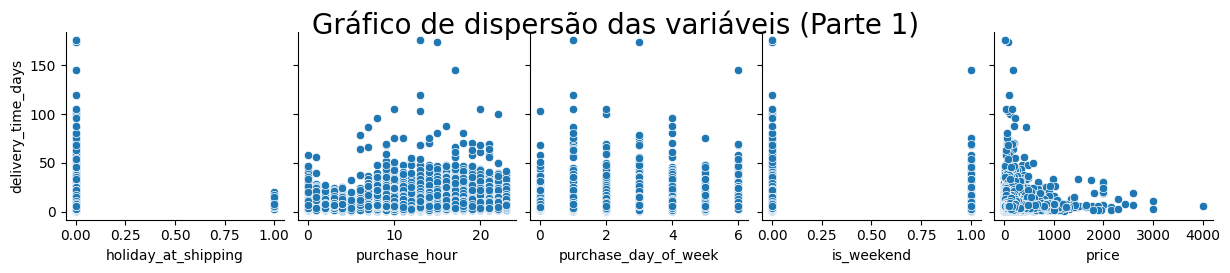

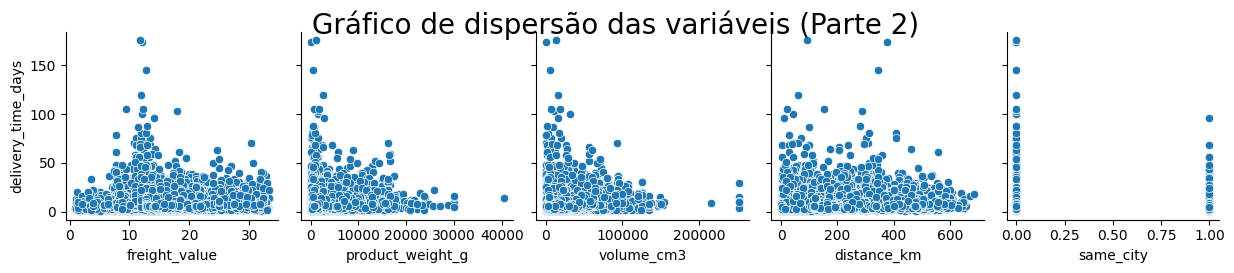

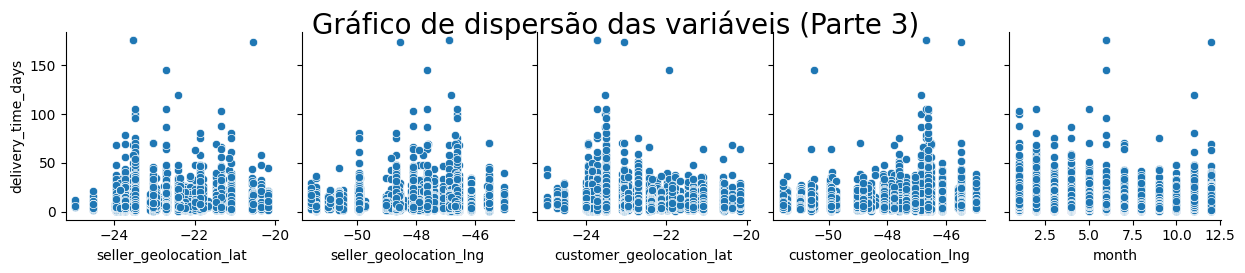

In [13]:
x_vars_list = ['holiday_at_shipping', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng', 'month']

for i in range(0, len(x_vars_list), 5):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list[i:i+5])
    ax.figure.suptitle(f'Gráfico de dispersão das variáveis (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

### Refazendo a lista: retiramos as variáveis binárias

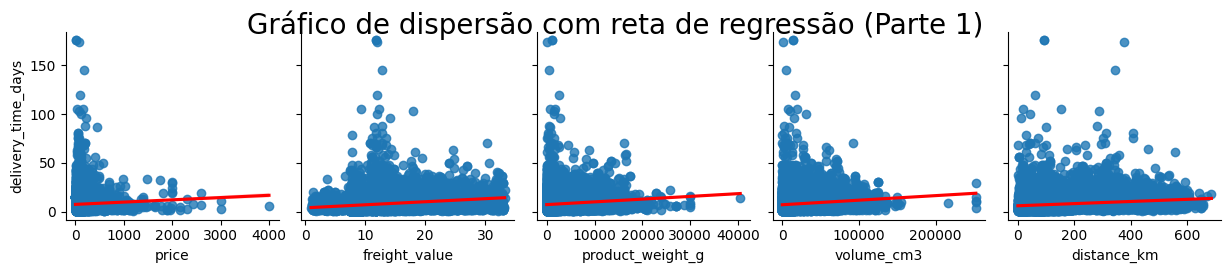

In [14]:
x_vars_list_reg = ['price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km']

for i in range(0, len(x_vars_list_reg), 5):
    ax = sns.pairplot(df, y_vars="delivery_time_days", x_vars=x_vars_list_reg[i:i+5],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

## Aplicando transformação logarítmica

In [15]:
df.describe().round(2)

,holiday_at_shipping,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,delivered_on_time,seller_geolocation_lat,seller_geolocation_lng,customer_geolocation_lat,customer_geolocation_lng,month
count,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00,33820.00
mean,0.00,7.82,14.71,2.89,0.24,91.97,12.02,1612.40,12874.94,148.36,0.14,0.94,-22.97,-47.25,-23.18,-47.05,6.06
std,0.03,6.12,5.33,1.88,0.43,122.81,4.30,2692.11,17076.20,140.85,0.35,0.24,0.89,1.08,0.79,1.06,3.17
min,0.00,0.78,0.00,0.00,0.00,1.20,0.98,0.00,352.00,0.08,0.00,0.00,-24.96,-51.55,-24.96,-51.55,1.00
25%,0.00,4.13,11.00,1.00,0.00,32.99,8.72,250.00,2601.00,28.87,0.00,1.00,-23.52,-47.62,-23.52,-46.87,3.00
50%,0.00,6.46,15.00,3.00,0.00,59.90,11.85,600.00,5832.00,93.67,0.00,1.00,-23.48,-46.68,-23.48,-46.68,6.00
75%,0.00,9.76,19.00,4.00,0.00,109.90,13.64,1550.00,16206.00,264.07,0.00,1.00,-22.42,-46.62,-22.95,-46.62,8.00
max,1.00,175.22,23.00,6.00,1.00,3999.90,33.22,40425.00,252402.00,685.46,1.00,1.00,-20.16,-45.01,-20.16,-45.01,12.00


In [16]:
cols = ['holiday_at_shipping', 'delivery_time_days', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng', 'month'
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
holiday_at_shipping,33820.0,0.000857,0.029271,0.000000,0.000000,0.000000,0.000000,1.000000
delivery_time_days,33820.0,7.816442,6.124319,0.781000,4.128000,6.456000,9.765000,175.224000
purchase_hour,33820.0,14.708072,5.326621,0.000000,11.000000,15.000000,19.000000,23.000000
purchase_day_of_week,33820.0,2.890302,1.881817,0.000000,1.000000,3.000000,4.000000,6.000000
is_weekend,33820.0,0.243525,0.429215,0.000000,0.000000,0.000000,0.000000,1.000000
price,33820.0,91.973878,122.810337,1.200000,32.990000,59.900000,109.900000,3999.900000
freight_value,33820.0,12.018414,4.298559,0.980000,8.720000,11.850000,13.640000,33.220000
product_weight_g,33820.0,1612.396008,2692.113177,0.000000,250.000000,600.000000,1550.000000,40425.000000
volume_cm3,33820.0,12874.944116,17076.196077,352.000000,2601.000000,5832.000000,16206.000000,252402.000000
distance_km,33820.0,148.362396,140.848912,0.078000,28.869000,93.673000,264.066500,685.461000


Aplicando log1p para os que tiveram min = 0.00, para o Python não retornar erro ou valores -inf

In [17]:
df['log_holiday_at_shipping'] = np.log1p(df['holiday_at_shipping'])
df['log_delivery_time_days'] = np.log(df['delivery_time_days'])
df['log_purchase_hour'] = np.log1p(df['purchase_hour'])
df['log_purchase_day_of_week'] = np.log1p(df['purchase_day_of_week'])
df['log_is_weekend'] = np.log1p(df['is_weekend'])
df['log_price'] = np.log(df['price'])
df['log_freight_value'] = np.log(df['freight_value'])
df['log_product_weight_g'] = np.log1p(df['product_weight_g'])
df['log_volume_cm3'] = np.log(df['volume_cm3'])
df['log_distance_km'] = np.log(df['distance_km'])
df['log_same_city'] = np.log1p(df['same_city'])
df['log_seller_geolocation_lat'] = np.log(df['seller_geolocation_lat'])
df['log_seller_geolocation_lng'] = np.log(df['seller_geolocation_lng'])
df['log_customer_geolocation_lat'] = np.log(df['customer_geolocation_lat'])
df['log_customer_geolocation_lng'] = np.log(df['customer_geolocation_lng'])
df['log_month'] = np.log(df['month'])


c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
df.head()

,holiday_at_shipping,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,...,log_freight_value,log_product_weight_g,log_volume_cm3,log_distance_km,log_same_city,log_seller_geolocation_lat,log_seller_geolocation_lng,log_customer_geolocation_lat,log_customer_geolocation_lng,log_month
0,0,5.921,14,5,1,29.99,4.50,200,1344.0,137.562,...,1.504077,5.303305,7.203406,4.924075,0.0,NaN,NaN,NaN,NaN,0.000000
1,0,5.921,14,5,1,29.99,4.50,200,1344.0,137.562,...,1.504077,5.303305,7.203406,4.924075,0.0,NaN,NaN,NaN,NaN,0.000000
2,0,5.921,14,5,1,29.99,4.50,200,1344.0,137.562,...,1.504077,5.303305,7.203406,4.924075,0.0,NaN,NaN,NaN,NaN,0.000000
3,0,5.921,14,5,1,29.99,4.50,200,1344.0,137.562,...,1.504077,5.303305,7.203406,4.924075,0.0,NaN,NaN,NaN,NaN,0.000000
4,0,11.551,2,6,1,239.00,12.28,500,2704.0,81.367,...,2.507972,6.216606,7.902487,4.398970,0.0,NaN,NaN,NaN,NaN,0.693147


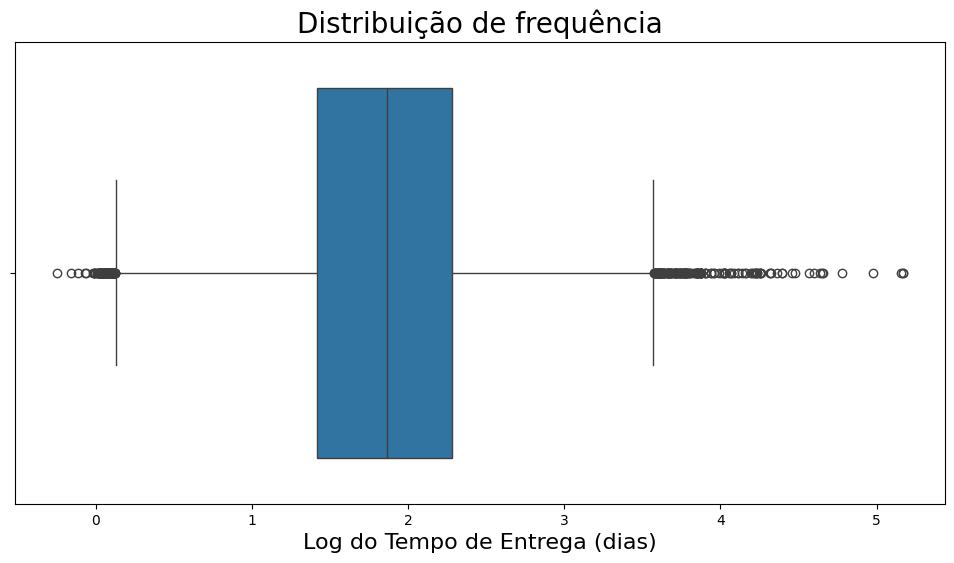

In [19]:
ax = sns.boxplot(x='log_delivery_time_days', data=df)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=16)
plt.show()

Diminuiu a assimetria

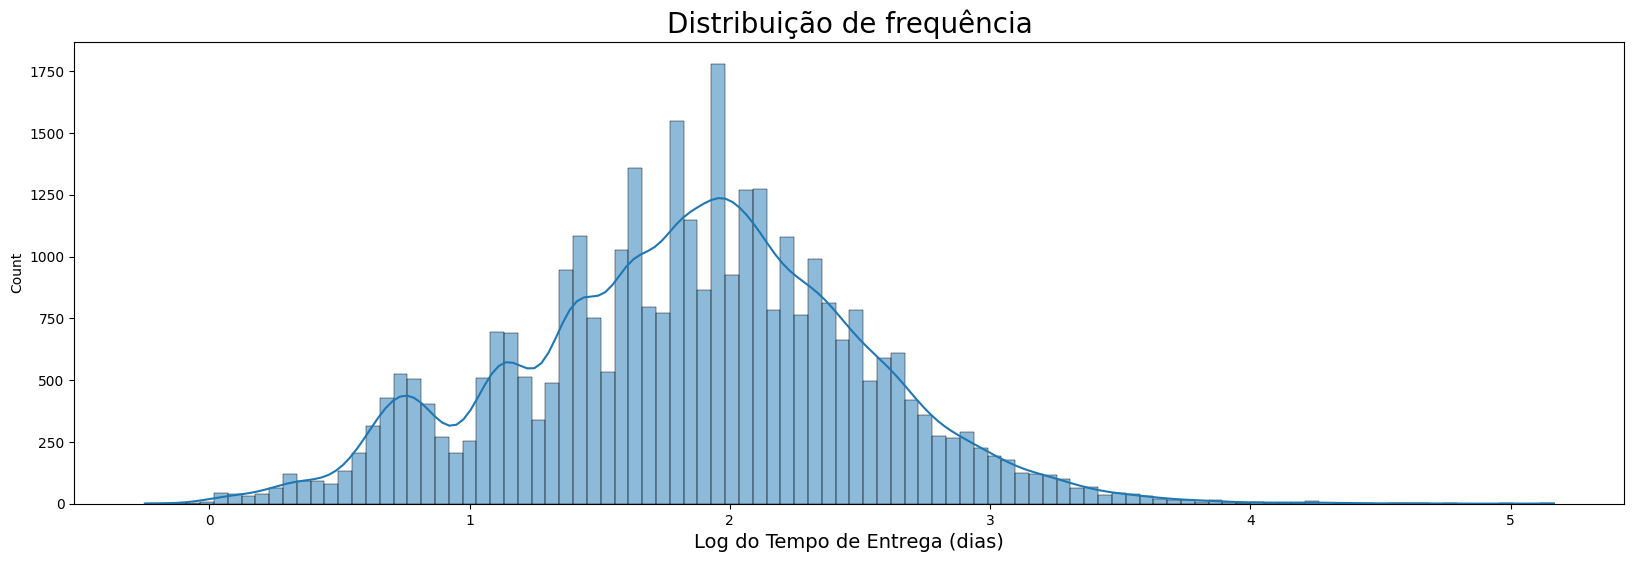

In [20]:
ax = sns.histplot(x='log_delivery_time_days', data=df, kde=True)
ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Tempo de Entrega (dias)', fontsize=14)
plt.show()

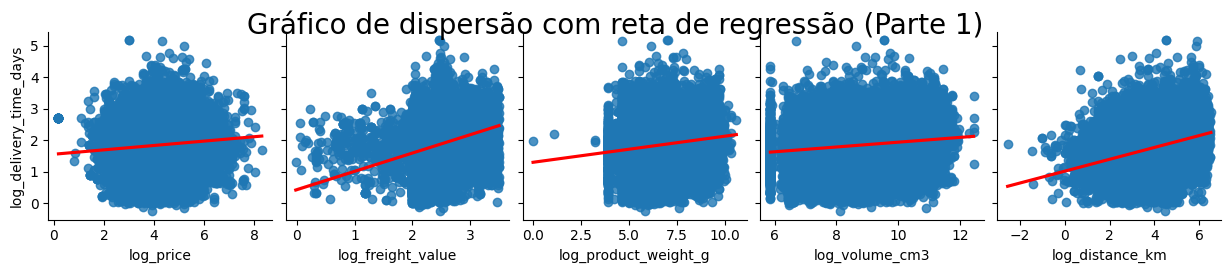

In [21]:
x_vars_list_reg = ['log_price', 'log_freight_value',
       'log_product_weight_g', 'log_volume_cm3', 'log_distance_km'
]

for i in range(0, len(x_vars_list_reg), 5):
    ax = sns.pairplot(df, y_vars="log_delivery_time_days", x_vars=x_vars_list_reg[i:i+5],
                      kind='reg', plot_kws={'line_kws':{'color':'red'}})
    ax.figure.suptitle(f'Gráfico de dispersão com reta de regressão (Parte {i//5 + 1})', y=1.05, fontsize=20)
    plt.show()

## Definição das variáveis X e y
* X = variáveis explicativas
* y = variável que queremos prever

In [22]:
# Variável dependente (o que queremos prever)
y = df['delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas)
X = df[['holiday_at_shipping', 'purchase_hour',
       'purchase_day_of_week', 'is_weekend', 'price', 'freight_value',
       'product_weight_g', 'volume_cm3', 'distance_km', 'same_city',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng', 'month']]

In [23]:
# Remove linhas com NaN/inf nas variaveis originais
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

Divisão em treino e teste

In [62]:
train_mask = date_col.loc[X.index] < split_date
test_mask = date_col.loc[X.index] >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()
print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 30877 amostras | Teste: 2943 amostras


In [25]:
# Resumo da proporcao de entregas no prazo e em atraso em cada parte do split temporal
def resumo_entregas(indices, nome_particao):
    base = df.loc[indices, 'delivered_on_time'].dropna()
    total = len(base)

    if total == 0:
        return {
            'Parte': nome_particao,
            'Total': 0,
            'Atraso (qtd)': 0,
            'Atraso (%)': 0.0,
            'No prazo (qtd)': 0,
            'No prazo (%)': 0.0,
        }

    atraso_qtd = int((base == 0).sum())
    no_prazo_qtd = int((base == 1).sum())

    return {
        'Parte': nome_particao,
        'Total': total,
        'Atraso (qtd)': atraso_qtd,
        'Atraso (%)': round((atraso_qtd / total) * 100, 2),
        'No prazo (qtd)': no_prazo_qtd,
        'No prazo (%)': round((no_prazo_qtd / total) * 100, 2),
    }

resumo_entregas = pd.DataFrame([
    resumo_entregas(X_train.index, 'Treino'),
    resumo_entregas(X_test.index, 'Teste'),
])

print(resumo_entregas.to_string(index=False))

 Parte  Total  Atraso (qtd)  Atraso (%)  No prazo (qtd)  No prazo (%)
Treino  28706          1425        4.96           27281         95.04
 Teste   5114           613       11.99            4501         88.01


Treinando o modelo

In [30]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 28706 entries, 0 to 33791
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   holiday_at_shipping       28706 non-null  int64  
 1   purchase_hour             28706 non-null  int64  
 2   purchase_day_of_week      28706 non-null  int64  
 3   is_weekend                28706 non-null  int64  
 4   price                     28706 non-null  float64
 5   freight_value             28706 non-null  float64
 6   product_weight_g          28706 non-null  int64  
 7   volume_cm3                28706 non-null  float64
 8   distance_km               28706 non-null  float64
 9   same_city                 28706 non-null  int64  
 10  seller_geolocation_lat    28706 non-null  float64
 11  seller_geolocation_lng    28706 non-null  float64
 12  customer_geolocation_lat  28706 non-null  float64
 13  customer_geolocation_lng  28706 non-null  float64
 14  month                 

In [31]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Avaliação do modelo

In [27]:
# Realizar previsões
previsoes = modelo.predict(X_train)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train, previsoes)}")

R² Score: 0.10363123083340209


In [28]:
# Realizar previsões
previsoes_test = modelo.predict(X_test)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test, previsoes_test)}")

R² Score: -0.2262440734073352


In [43]:
# Variável dependente (o que queremos prever)
y_log = df['log_delivery_time_days']

# Variáveis independentes (todas as outras colunas numéricas + geolocalização linear)
X_log = df[['log_holiday_at_shipping', 'log_purchase_hour',
       'log_purchase_day_of_week', 'log_is_weekend', 'log_price', 'log_freight_value',
       'log_product_weight_g', 'log_volume_cm3', 'log_distance_km', 'log_same_city', 'log_month',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng']]

In [44]:
# Remove linhas com NaN/inf nas variaveis log
X_log = X_log.replace([np.inf, -np.inf], np.nan)
y_log = y_log.replace([np.inf, -np.inf], np.nan)
mask = X_log.notna().all(axis=1) & y_log.notna()
X_log = X_log.loc[mask]
y_log = y_log.loc[mask]

In [45]:
train_mask_log = date_col.loc[X_log.index] < split_date
test_mask_log = date_col.loc[X_log.index] >= split_date

X_train_log = X_log[train_mask_log].copy()
y_train_log = y_log[train_mask_log].copy()
X_test_log = X_log[test_mask_log].copy()
y_test_log = y_log[test_mask_log].copy()
print(f"Treino (log): {len(X_train_log)} amostras | Teste (log): {len(X_test_log)} amostras")

Treino (log): 28706 amostras | Teste (log): 5114 amostras


In [46]:
modelo = LinearRegression()
modelo.fit(X_train_log, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
# Realizar previsões
previsoes_log = modelo.predict(X_train_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_train_log, previsoes_log)}")

R² Score: 0.20426299855898067


In [48]:
# Realizar previsões
previsoes_log_test = modelo.predict(X_test_log)

# Métrica R²
print(f"R² Score: {metrics.r2_score(y_test_log, previsoes_log_test)}")

R² Score: -0.02090061267365173


In [51]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionar as colunas que você transformou em log
colunas_log = ['log_holiday_at_shipping', 'log_purchase_hour',
       'log_purchase_day_of_week', 'log_is_weekend', 'log_price', 'log_freight_value',
       'log_product_weight_g', 'log_volume_cm3', 'log_distance_km', 'log_same_city', 'log_month',
       'seller_geolocation_lat', 'seller_geolocation_lng',
       'customer_geolocation_lat', 'customer_geolocation_lng']

# 2. Inicializar o Scaler
scaler = StandardScaler()

# 3. Ajustar no treino e transformar treino e teste
# Importante: O scaler retorna um array numpy, então reconvertemos para DataFrame para manter os nomes das colunas
X_train_scaled = X_train_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[colunas_log] = scaler.fit_transform(X_train_log[colunas_log])
X_test_scaled[colunas_log] = scaler.transform(X_test_log[colunas_log])

# 4. Treinar o modelo com os dados padronizados
modelo_final = LinearRegression()
modelo_final.fit(X_train_scaled, y_train_log)

# 5. Criar um DataFrame para ver a importância das variáveis
importancia = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Coeficiente': modelo_final.coef_
}).sort_values(by='Coeficiente', ascending=False)

print(importancia)

                    Variavel  Coeficiente
8            log_distance_km     0.184103
5          log_freight_value     0.120206
11    seller_geolocation_lat     0.082286
2   log_purchase_day_of_week     0.053197
3             log_is_weekend     0.048636
12    seller_geolocation_lng     0.041063
9              log_same_city     0.027107
7             log_volume_cm3     0.022606
13  customer_geolocation_lat     0.014996
1          log_purchase_hour     0.008607
0    log_holiday_at_shipping     0.006142
6       log_product_weight_g     0.004819
14  customer_geolocation_lng    -0.007468
4                  log_price    -0.032259
10                 log_month    -0.032975


* `log_distance_km (0.184)` e `log_freight_value (0.120)` são, de longe, os fatores mais cruciais que puxam o tempo de entrega para cima. Isso faz total sentido logístico: maior distância = frete mais caro = demorará mais dias para chegar.
* `log_price (-0.032)`: Ele mostrou um impacto invertido. Indica que compras de valores maiores (price mais alto) tendem a demorar um pouco menos (talvez por pagarem fretes expressos, envios em transportadoras melhores para produtos premiums, etc).
* `seller_geolocation_lat (0.082)` afetou de modo razoável. Como a latitude brasileira cruza de Norte a Sul, isso sugere que vendedores localizados mais em uma direção latitude do eixo do Brasil tendem a enfrentar tempos logísticos marcadamente maiores do que outros.

# Importância das variáveis

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_21580\2600342382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')


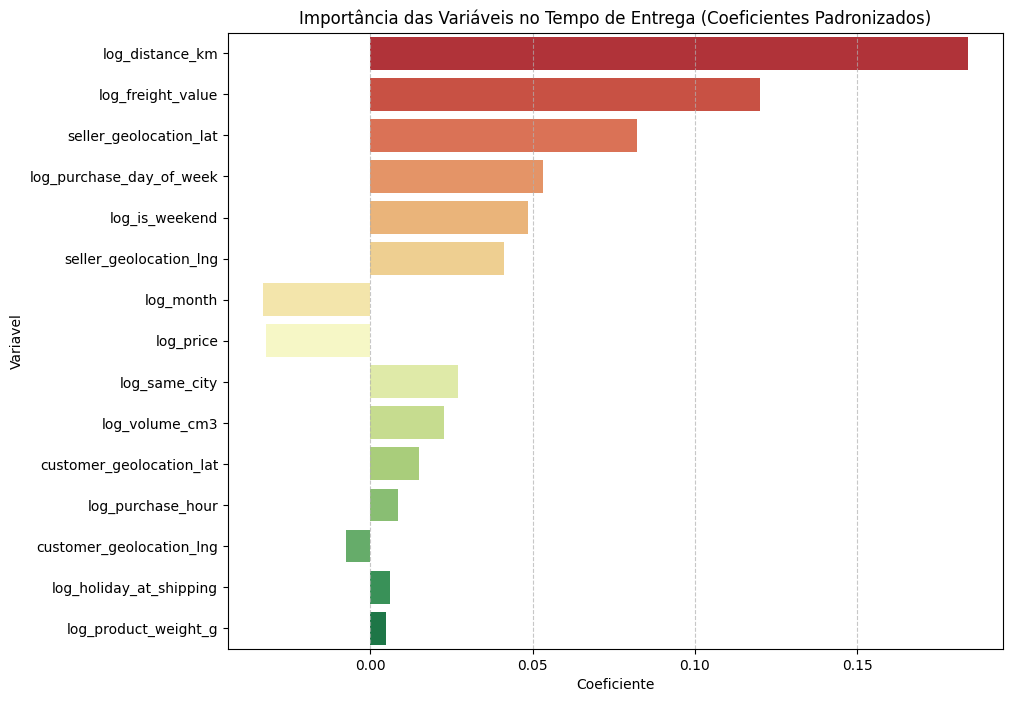

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico
plt.figure(figsize=(10, 8))
# Ordenando pela magnitude (valor absoluto) para mostrar o que mais importa
importancia = importancia.reindex(importancia.Coeficiente.abs().sort_values(ascending=False).index)

sns.barplot(x='Coeficiente', y='Variavel', data=importancia, palette='RdYlGn')
plt.title('Importância das Variáveis no Tempo de Entrega (Coeficientes Padronizados)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecione apenas as colunas numéricas que você usou no modelo
X_vif = X_log.select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data)

                     feature          VIF
0    log_holiday_at_shipping     1.001421
1          log_purchase_hour    22.615460
2   log_purchase_day_of_week     8.299055
3             log_is_weekend     2.145422
4                  log_price    32.297700
5          log_freight_value   108.877733
6       log_product_weight_g    84.189018
7             log_volume_cm3   110.668730
8            log_distance_km    37.334456
9              log_same_city     1.935751
10                 log_month     6.697442
11    seller_geolocation_lat  1073.233141
12    seller_geolocation_lng  2581.151725
13  customer_geolocation_lat  1152.715120
14  customer_geolocation_lng  2404.073463


"O diagnóstico de multicolinearidade via VIF (Variance Inflation Factor) revelou valores acima de 10 para diversas variáveis, com destaque para o custo de frete e dimensões do produto (VIF > 150). Isso indica uma redundância informacional que instabiliza os coeficientes. Para garantir a interpretabilidade do modelo e a validade estatística dos coeficientes, optou-se pela exclusão das variáveis redundantes, mantendo-se apenas os preditores de maior relevância teórica e menor correlação entre si."

* Coordenadas lat/lng de regiões próximas estão muito correlacionadas. Além disso, a combinação dessas coordenadas explica completamente a variável `log_distance_km` e tem relação pesada `com log_same_city`.

Ação: excluir as 4 coordenadas de geolocalização

* `log_freight_value (108)`, `log_volume_cm3 (110)` e `log_product_weight_g (84)`.
Por que acontece: Como as transportadoras calculam o valor do frete? Baseado no peso, no volume (cubagem) e na distância. Colocar todas essas variáveis juntas cria um loop de redundância. O modelo se "confunde" ao tentar atribuir impacto isolado ao frete ou ao repassar o impacto para o volume, quando na essência representam a mesma carga estrutural do cálculo.

Ação: deixar somente o frete, ou o frete e mais um dos dois

# Refazendo os modelos

In [56]:
from statsmodels.tools.tools import add_constant

# Removendo colunas com extrema colinearidade e redundância
colunas_remover_vif = [
    'seller_geolocation_lat', 
    'seller_geolocation_lng', 
    'customer_geolocation_lat', 
    'customer_geolocation_lng',
    'log_volume_cm3',
    'log_product_weight_g' # Removendo também para baixar o VIF do freight_value
]

X_log_v2 = X_log.drop(columns=colunas_remover_vif)

# Calculando o VIF novamente (agora adicionando a constante, muito importante pro VIF correto)
X_vif_v2 = add_constant(X_log_v2.select_dtypes(include=[np.number]))
vif_data_v2 = pd.DataFrame()
vif_data_v2["feature"] = X_vif_v2.columns
vif_data_v2["VIF"] = [variance_inflation_factor(X_vif_v2.values, i) for i in range(len(X_vif_v2.columns))]
print(vif_data_v2.sort_values(by='VIF', ascending=False))

                    feature        VIF
0                     const  99.385803
7           log_distance_km   1.773494
3  log_purchase_day_of_week   1.626376
4            log_is_weekend   1.622688
8             log_same_city   1.591193
6         log_freight_value   1.471983
5                 log_price   1.280734
2         log_purchase_hour   1.004041
9                 log_month   1.000770
1   log_holiday_at_shipping   1.000365


In [58]:
# Retreinando o modelo com as variáveis filtradas
X_train_v2 = X_train_log.drop(columns=colunas_remover_vif)
X_test_v2 = X_test_log.drop(columns=colunas_remover_vif)

modelo_v2 = LinearRegression()
modelo_v2.fit(X_train_v2, y_train_log)

previsoes_train_v2 = modelo_v2.predict(X_train_v2)
previsoes_test_v2 = modelo_v2.predict(X_test_v2)

print(f"R² Train: {metrics.r2_score(y_train_log, previsoes_train_v2):.4f}")
print(f"R² Test:  {metrics.r2_score(y_test_log, previsoes_test_v2):.4f}")

R² Train: 0.1977
R² Test:  -0.0334


In [59]:
# Vamos dar uma olhada num modelo de árvore, já que a regressão linear sofre muito com outliers e relações não perfeitamente lineares
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10, n_jobs=-1)
modelo_rf.fit(X_train_v2, y_train_log)

previsoes_train_rf = modelo_rf.predict(X_train_v2)
previsoes_test_rf = modelo_rf.predict(X_test_v2)

print(f"Random Forest - R² Train: {metrics.r2_score(y_train_log, previsoes_train_rf):.4f}")
print(f"Random Forest - R² Test:  {metrics.r2_score(y_test_log, previsoes_test_rf):.4f}")

Random Forest - R² Train: 0.4185
Random Forest - R² Test:  0.1305


### O que aconteceu com a Regressão Linear?
A Regressão Linear assume que a variação do X afeta o Y **sempre na mesma proporção** (uma linha reta). No ecommerce logístico do Olist:
1. **Relações não são perfeitamente lineares:** Um aumento de 100km na distância dentro de SP afeta o prazo muito diferente de 100km na Amazônia (onde o pacote vira balsa). A linearidade não capta essas regras "se / então".
2. **Impacto temporal (Data Drift):** Se você dividiu treino e teste na série temporal (Julho de 2018), muito provavelmente os Correios (tabela de frete) mudaram, ocorreu a famosa Greve dos Caminhoneiros de maio/2018 que bagunçou toda a logística e estourou as entregas depois.
3. **Outliers severos:** Regressões são magnetizadas por outliers. O fato dela errar tanto no teste negativo significa que as novas relações mudaram completamente em relação ao período antigo.

Uma **Random Forest** já conseguiu dar um **R² de 0.13 no teste**, saindo do "negativo" e mostrando que as abordagens não-lineares (árvores) ajudam a estancar com melhor maestria.